# Heart Disease Risk Prediction

## 1. Getting Our Tools Ready

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Tools are ready!")

Tools are ready!


## 2. Loading the Data

We are using the Coronary Health dataset.  
It contains medical information about 70,000 people and whether they have heart disease or not.

In [11]:
df = pd.read_excel(r"C:\Users\Earlycode\Documents\bosede_pythonclass\Bosede Project\Coronary health_data.xlsx")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (70000, 14)

First 5 rows:


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,1,168,62.0,110,80,0,0,0,0,1,0
1,1,1,20228,0,156,85.0,140,90,2,0,0,0,1,1
2,2,2,18857,0,165,64.0,130,70,2,0,0,0,0,1
3,3,3,17623,1,169,82.0,150,100,0,0,0,0,1,1
4,4,4,17474,0,156,56.0,100,60,0,0,0,0,0,0


### What the important columns mean:
- **age** → Age of the person (in days – we will convert it to years)
- **gender** → 1 = Male, 0 = Female (or vice versa)
- **smoke** → Does the person smoke? (1 = Yes, 0 = No)
- **alco** → Does the person drink alcohol? (1 = Yes, 0 = No)
- **active** → Is the person physically active? (1 = Yes, 0 = No)
- **cardio** → Does the person have heart disease? (1 = Yes, 0 = No)  ← This is what we want to predict

## 3. Preparing the Data for Our Goal

We only need **Age**, **Gender**, and **Lifestyle** information.

In [12]:
# Convert age from days to years
df['age_years'] = (df['age'] / 365).round().astype(int)

# Create a simple Lifestyle Score
# Higher score = healthier lifestyle
# active = +1, smoke = -1, alco = -1
df['lifestyle_score'] = df['active'] - df['smoke'] - df['alco']

# Select only the columns we care about
data = df[['age_years', 'gender', 'smoke', 'alco', 'active', 'lifestyle_score', 'cardio']].copy()

print("Data ready for modeling:")
data.head()

Data ready for modeling:


,age_years,gender,smoke,alco,active,lifestyle_score,cardio
0,50,1,0,0,1,1,0
1,55,0,0,0,1,1,1
2,52,0,0,0,0,0,1
3,48,1,0,0,1,1,1
4,48,0,0,0,0,0,0


## 4. Looking at the Data

In [13]:
print("How many people have heart disease?")
print(data['cardio'].value_counts())
print("\n0 = Low Risk (No disease)")
print("1 = High Risk (Has disease)")

print("\nAverage age:", data['age_years'].mean().round(1), "years")

How many people have heart disease?
cardio
0    35021
1    34979
Name: count, dtype: int64

0 = Low Risk (No disease)
1 = High Risk (Has disease)

Average age: 53.3 years


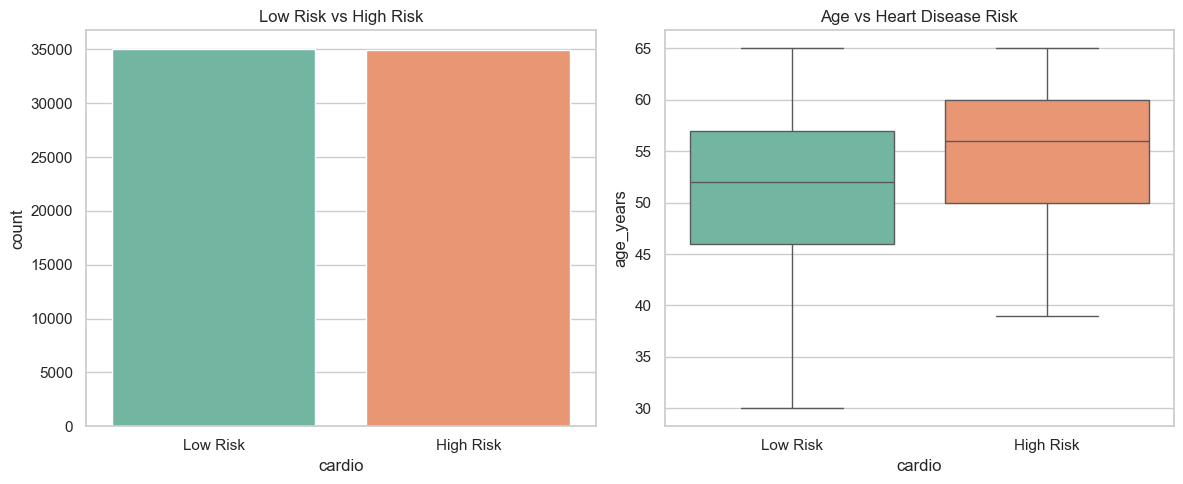

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='cardio', data=data, palette='Set2')
plt.title('Low Risk vs High Risk')
plt.xticks([0, 1], ['Low Risk', 'High Risk'])

plt.subplot(1, 2, 2)
sns.boxplot(x='cardio', y='age_years', data=data, palette='Set2')
plt.title('Age vs Heart Disease Risk')
plt.xticks([0, 1], ['Low Risk', 'High Risk'])

plt.tight_layout()
plt.show()

## 5. Preparing Features and Target

In [15]:
# Features we will use
X = data[['age_years', 'gender', 'smoke', 'alco', 'active']]
y = data['cardio']   # 0 = Low Risk, 1 = High Risk

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (56000, 5)
Testing set size: (14000, 5)


## 6. Training the Models

In [16]:
# Model 1: Logistic Regression (simple and easy to understand)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Model 2: Random Forest (usually stronger)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


## 7. Checking How Good the Models Are

In [17]:
print("=== Logistic Regression ===")
log_pred = log_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, log_pred)*100:.1f}%")
print(classification_report(y_test, log_pred, target_names=['Low Risk', 'High Risk']))

print("\n=== Random Forest ===")
rf_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, rf_pred)*100:.1f}%")
print(classification_report(y_test, rf_pred, target_names=['Low Risk', 'High Risk']))

=== Logistic Regression ===
Accuracy: 59.4%
              precision    recall  f1-score   support

    Low Risk       0.60      0.58      0.59      7004
   High Risk       0.59      0.61      0.60      6996

    accuracy                           0.59     14000
   macro avg       0.59      0.59      0.59     14000
weighted avg       0.59      0.59      0.59     14000


=== Random Forest ===
Accuracy: 59.2%
              precision    recall  f1-score   support

    Low Risk       0.59      0.58      0.59      7004
   High Risk       0.59      0.60      0.60      6996

    accuracy                           0.59     14000
   macro avg       0.59      0.59      0.59     14000
weighted avg       0.59      0.59      0.59     14000



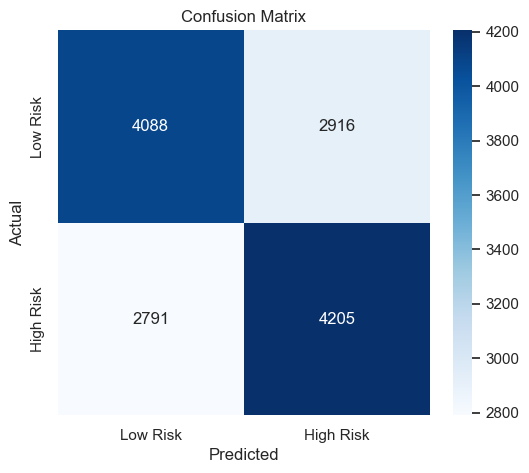

In [18]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 8. What Matters Most?

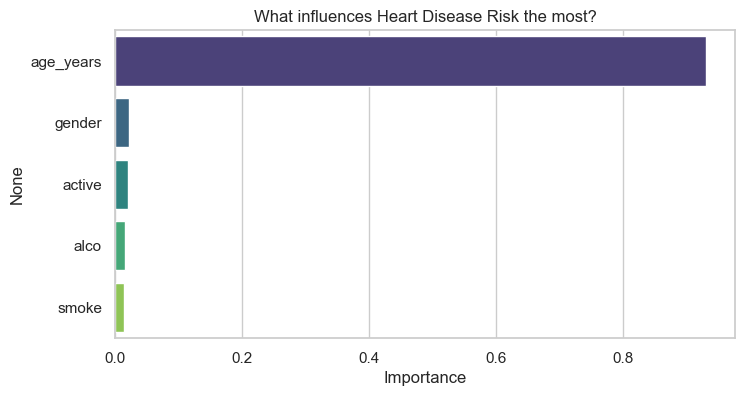

age_years    0.929468
gender       0.021097
active       0.020061
alco         0.015844
smoke        0.013529
dtype: float64


In [19]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importance.values, y=importance.index, palette='viridis')
plt.title('What influences Heart Disease Risk the most?')
plt.xlabel('Importance')
plt.show()

print(importance)

## 9. Predict Risk for a New Person

In [20]:
# Example person:
# 55 years old, Male (1), Smokes (1), Drinks alcohol (1), Not active (0)

new_person = pd.DataFrame({
    'age_years': [55],
    'gender': [1],      # 1 = Male, 0 = Female
    'smoke': [1],       # 1 = Yes, 0 = No
    'alco': [1],        # 1 = Yes, 0 = No
    'active': [0]       # 1 = Active, 0 = Not active
})

prediction = rf_model.predict(new_person)[0]
probability = rf_model.predict_proba(new_person)[0]

print("Prediction:", "High Risk" if prediction == 1 else "Low Risk")
print(f"Probability of High Risk: {probability[1]*100:.1f}%")
print(f"Probability of Low Risk : {probability[0]*100:.1f}%")

Prediction: High Risk
Probability of High Risk: 65.5%
Probability of Low Risk : 34.5%


## 10. Save the Model

In [21]:
# Save the best model
joblib.dump(rf_model, "heart_disease_risk_model.joblib")

print("Model saved successfully as 'heart_disease_risk_model.joblib'")

Model saved successfully as 'heart_disease_risk_model.joblib'


### How to use the saved model later:

```python
model = joblib.load("heart_disease_risk_model.joblib")

new_person = pd.DataFrame({
    'age_years': [45],
    'gender': [0],
    'smoke': [0],
    'alco': [0],
    'active': [1]
})

prediction = model.predict(new_person)[0]
print("High Risk" if prediction == 1 else "Low Risk")
```

In [22]:
data.columns.to_list()

['age_years', 'gender', 'smoke', 'alco', 'active', 'lifestyle_score', 'cardio']